# Toy models for parameter estimation

**Day 2, 14:30 — 30 minutes.** Alexander Fengler.

This session is the bridge. At 12:00 you built models in PyMC. At 14:00 you
simulated from cognitive models. Now we put the two together: **a
drift-diffusion likelihood dropped straight into a PyMC model**, fitted the
way you already know how to fit things.

We will not explain *how* the DDM likelihood works — that is tomorrow. Today
it is simply a distribution you can use, exactly like `pm.Normal`.

The shape of this session is a *miniature scientific workflow*.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

from ssms import Simulator
from hssm.likelihoods import DDM        # <- the DDM as a PyMC distribution

RANDOM_SEED = sum(map(ord, "sbi4cogsci-toy"))
rng = np.random.default_rng(RANDOM_SEED)

DRAWS, TUNE, CHAINS = 800, 800, 2

print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 6.2.0 | arviz 1.2.0


## 1. The data

A two-alternative decision task. Every trial has two design features:

- **coherence** — how much evidence the stimulus carries: `low`, `medium`, `high`
- **emphasis** — the instruction given: respond `speed`-fast or `accuracy`-carefully

250 trials in each of the six cells, so 500 trials per coherence level and
1500 in total. This is a synthetic dataset: something specific generated it,
and by the end of the session you will know what.

In [2]:
CONDITIONS = ["low", "medium", "high"]
EMPHASES = ["speed", "accuracy"]
N_PER_CELL = 250

# --- the generating process (do not peek at the values until section 5) ------
_V_BY_COHERENCE = {"low": 0.35, "medium": 0.85, "high": 1.5}
_A_BY_EMPHASIS = {"speed": 0.9, "accuracy": 1.6}
_Z_TRUE, _T_TRUE = 0.5, 0.30

rows = []
for coh in CONDITIONS:
    for emp in EMPHASES:
        theta = [_V_BY_COHERENCE[coh], _A_BY_EMPHASIS[emp], _Z_TRUE, _T_TRUE]
        out = Simulator(model="ddm").simulate(
            theta=theta, n_samples=N_PER_CELL,
            random_state=RANDOM_SEED + hash((coh, emp)) % 1000)
        rows.append(pd.DataFrame({
            "rt": out["rts"].flatten(),
            "response": out["choices"].flatten().astype(int),
            "coherence": coh,
            "emphasis": emp,
        }))

data = pd.concat(rows, ignore_index=True)
data["coherence"] = pd.Categorical(data["coherence"], categories=CONDITIONS, ordered=True)
data["emphasis"] = pd.Categorical(data["emphasis"], categories=EMPHASES)
print(data.head())
print(f"\n{len(data)} trials")

         rt  response coherence emphasis
0  1.858614        -1       low    speed
1  0.593165        -1       low    speed
2  0.524136         1       low    speed
3  0.892757         1       low    speed
4  1.332736         1       low    speed

1500 trials


### Look before you fit

Two summaries answer most of the question: how *accurate* is each cell, and
how *fast*?

In [3]:
summary = (data.assign(correct=lambda d: d["response"] == 1)
               .groupby(["coherence", "emphasis"], observed=True)
               .agg(accuracy=("correct", "mean"), mean_rt=("rt", "mean"))
               .round(3))
print(summary.to_string())

                    accuracy  mean_rt
coherence emphasis                   
low       speed        0.608    1.071
          accuracy     0.728    2.573
medium    speed        0.852    1.021
          accuracy     0.964    2.050
high      speed        0.944    0.842
          accuracy     0.984    1.409


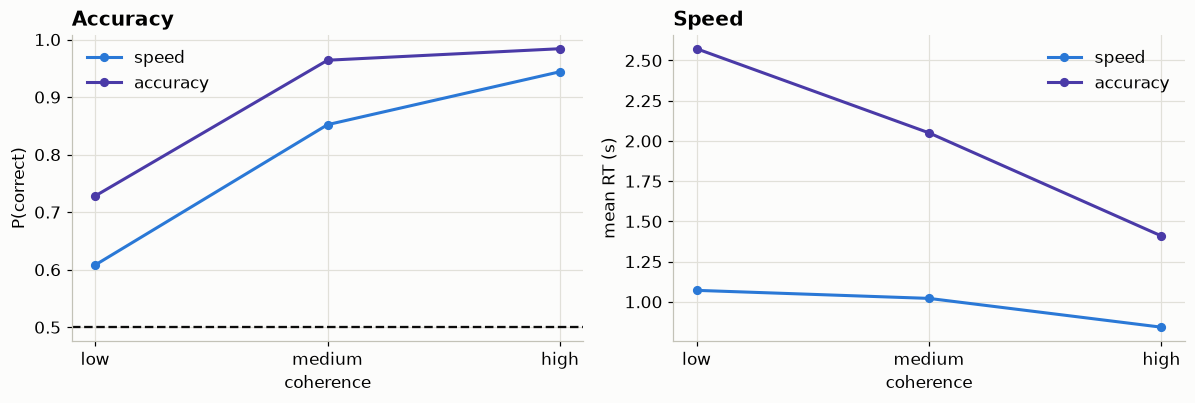

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(len(CONDITIONS))
for emp, colour in [("speed", S.PRIMARY), ("accuracy", S.NAIVE)]:
    sub = summary.xs(emp, level="emphasis")
    ax1.plot(x, sub["accuracy"], "o-", color=colour, label=emp)
    ax2.plot(x, sub["mean_rt"], "o-", color=colour, label=emp)
for ax, ylab, title in [(ax1, "P(correct)", "Accuracy"), (ax2, "mean RT (s)", "Speed")]:
    ax.set(xticks=x, xlabel="coherence", ylabel=ylab, title=title)
    ax.set_xticklabels(CONDITIONS)
    ax.legend()
S.truth_line(ax1, 0.5, label="chance")
fig.tight_layout()

Two patterns:

- Accuracy climbs steeply with coherence, and barely moves with emphasis.
- Mean RT is dominated by emphasis, and moves comparatively little with
  coherence.

A model with one drift rate and one boundary for the whole dataset cannot
produce that. Something has to vary — the question is *what*.

> **Poll.** Before fitting: which parameter should coherence affect?
>
> - **A.** Boundary separation $a$ — harder stimuli need more evidence.
> - **B.** Drift rate $v$ — coherence is how fast evidence accumulates.
> - **C.** Non-decision time $t$ — harder stimuli take longer to encode.
> - **D.** Start point $z$ — coherence biases you toward one response.

<details>
<summary>Answer</summary>

**B.** Drift rate is the *quality of evidence per unit time*, which is
exactly what a coherence manipulation changes. Boundary separation is how
much evidence you demand before committing — that is under the participant's
strategic control, which is what a speed/accuracy instruction manipulates.
Keep that mapping: **stimulus → drift, instruction → boundary.**

</details>

## 2. The DDM as a PyMC distribution

Here is the whole bridge:

```python
from hssm.likelihoods import DDM
DDM("obs", v=..., a=..., z=..., t=..., observed=observed)
```

It behaves like any other PyMC distribution, with two differences:

1. its `observed` data is **two columns**, `[rt, response]`, not one, and
2. `response` must be coded **`-1` / `+1`**.

The model we fit first is the simplest possible one — a single set of
parameters for all 1500 trials:

$$
v \sim \text{Normal}(0, 3), \quad a \sim \text{HalfNormal}(2), \quad
z \sim \text{Beta}(5,5), \quad t \sim \text{HalfNormal}(0.5),
$$
$$
(\text{rt}_i, \text{resp}_i) \sim \text{DDM}(v,\ a,\ z,\ t).
$$

In [5]:
observed = np.column_stack([data["rt"].to_numpy(), data["response"].to_numpy()])
coh_idx = data["coherence"].cat.codes.to_numpy()
emp_idx = data["emphasis"].cat.codes.to_numpy()

COORDS = {"coherence": CONDITIONS, "emphasis": EMPHASES}


def fit(model, seed=RANDOM_SEED):
    with model:
        return pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
                         nuts_sampler="pymc", progressbar=False, random_seed=seed,
                         idata_kwargs={"log_likelihood": True})


with pm.Model(coords=COORDS) as m1_flat:
    # Priors
    v = pm.Normal("v", 0.0, 3.0)
    a = pm.HalfNormal("a", 2.0)
    z = pm.Beta("z", 5.0, 5.0)
    t = pm.HalfNormal("t", 0.5)
    # Likelihood
    DDM("obs", v=v, a=a, z=z, t=t, observed=observed)

idata_flat = fit(m1_flat)
print(az.summary(idata_flat, var_names=["v", "a", "z", "t"], kind="stats").to_string())

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 291 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


   mean     sd eti89_lb eti89_ub
v  0.64  0.031     0.59     0.69
a   1.2  0.018      1.2      1.3
z  0.52   0.01      0.5     0.54
t  0.24  0.012     0.22     0.25


It sampled, it converged, and the numbers look perfectly reasonable. That is
the trap: **a model that fits nothing in particular still returns a tidy
answer.** You only find out by asking it to reproduce the data.

Sampling: [obs]


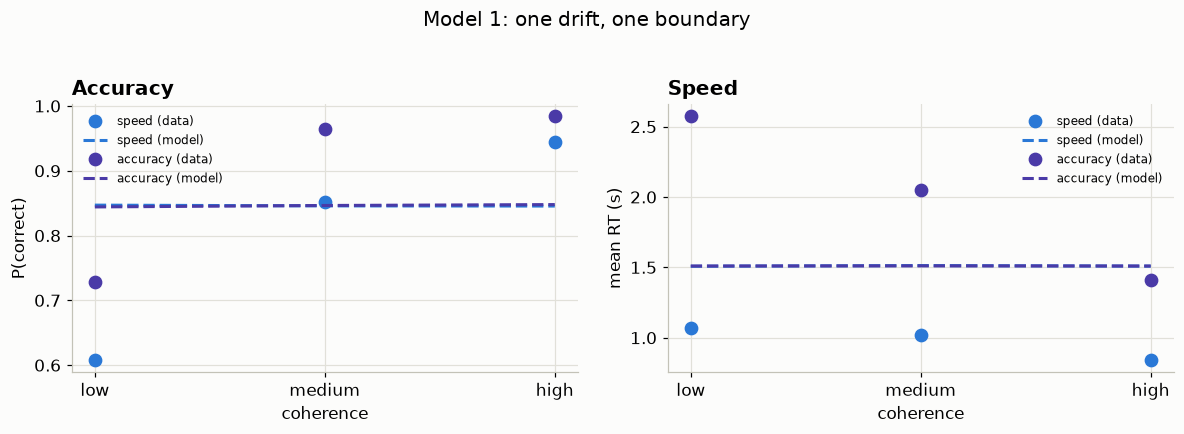

In [6]:
def cell_predictions(idata, model, n_keep=200):
    """Posterior-predictive accuracy and mean RT, per design cell.

    `sample_posterior_predictive` has no `draws` argument — it uses every
    posterior draw — so we thin afterwards to keep this quick.
    """
    with model:
        ppc = pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED,
                                             progressbar=False)
    sim = ppc["posterior_predictive"].dataset["obs"].values   # (chain, draw, obs, 2)
    sim = sim.reshape(-1, sim.shape[-2], sim.shape[-1])
    if sim.shape[0] > n_keep:                       # thin for speed
        sel = np.linspace(0, sim.shape[0] - 1, n_keep).astype(int)
        sim = sim[sel]
    out = []
    for coh in CONDITIONS:
        for emp in EMPHASES:
            mask = (data["coherence"] == coh) & (data["emphasis"] == emp)
            mask = mask.to_numpy()
            out.append({"coherence": coh, "emphasis": emp,
                        "accuracy": float((sim[:, mask, 1] == 1).mean()),
                        "mean_rt": float(sim[:, mask, 0].mean())})
    return pd.DataFrame(out).set_index(["coherence", "emphasis"])


pred_flat = cell_predictions(idata_flat, m1_flat)


def compare_plot(preds, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
    xx = np.arange(len(CONDITIONS))
    for emp, colour in [("speed", S.PRIMARY), ("accuracy", S.NAIVE)]:
        obs_s = summary.xs(emp, level="emphasis")
        pre_s = preds.xs(emp, level="emphasis")
        ax1.plot(xx, obs_s["accuracy"], "o", color=colour, ms=8, label=f"{emp} (data)")
        ax1.plot(xx, pre_s["accuracy"], "--", color=colour, label=f"{emp} (model)")
        ax2.plot(xx, obs_s["mean_rt"], "o", color=colour, ms=8, label=f"{emp} (data)")
        ax2.plot(xx, pre_s["mean_rt"], "--", color=colour, label=f"{emp} (model)")
    for ax, ylab, sub in [(ax1, "P(correct)", "Accuracy"), (ax2, "mean RT (s)", "Speed")]:
        ax.set(xticks=xx, xlabel="coherence", ylabel=ylab, title=sub)
        ax.set_xticklabels(CONDITIONS)
        ax.legend(fontsize=8)
    fig.suptitle(title, y=1.03)
    fig.tight_layout()


compare_plot(pred_flat, "Model 1: one drift, one boundary")

Circles are the data, dashed lines are the model. The model predicts **one
number per panel** — flat lines — because it has no way to know which cell a
trial came from. It splits the difference and gets everything wrong.

## 3. Your turn: propose a better model

You have four parameters and two design features. Let coherence and/or
emphasis act on whichever parameters you think should carry them.

In raw PyMC that is an index into a vector of parameters:

```python
with pm.Model(coords=COORDS) as m:
    v = pm.Normal("v", 0.0, 3.0, dims="coherence")   # one drift per level
    ...
    DDM("obs", v=v[coh_idx], a=a, z=z, t=t, observed=observed)
```

`coh_idx` is an integer per trial saying which coherence level it belongs to,
so `v[coh_idx]` is a per-trial drift rate. Nothing else changes.

**Spend five minutes.** Fit at least one alternative and look at its
predictions with `compare_plot`. Below are the two we will carry forward.

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 14 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling: [obs]


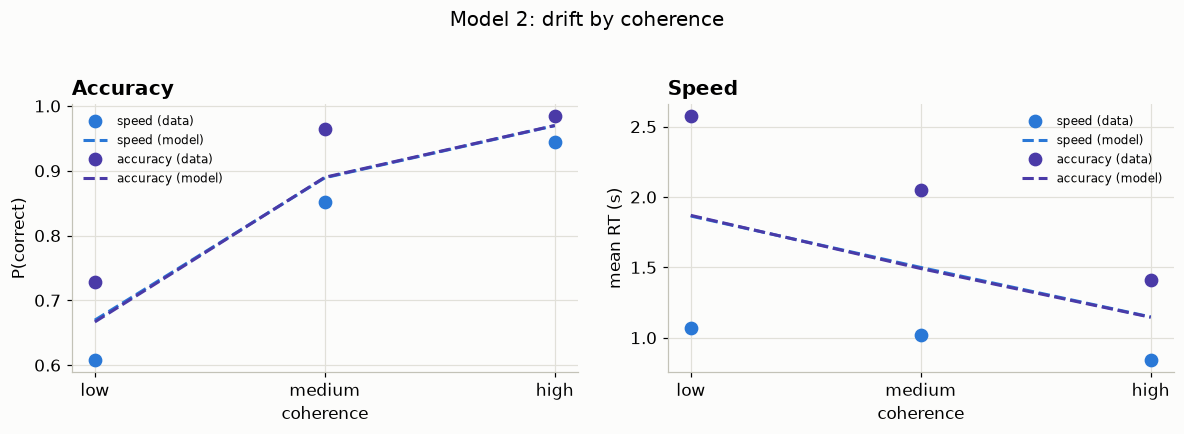

In [7]:
# Model 2: drift varies by coherence; one boundary for everyone.
with pm.Model(coords=COORDS) as m2_drift:
    # Priors
    v = pm.Normal("v", 0.0, 3.0, dims="coherence")
    a = pm.HalfNormal("a", 2.0)
    z = pm.Beta("z", 5.0, 5.0)
    t = pm.HalfNormal("t", 0.5)
    # Likelihood
    DDM("obs", v=v[coh_idx], a=a, z=z, t=t, observed=observed)

idata_drift = fit(m2_drift)
pred_drift = cell_predictions(idata_drift, m2_drift)
compare_plot(pred_drift, "Model 2: drift by coherence")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 741 seconds.


Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [obs]


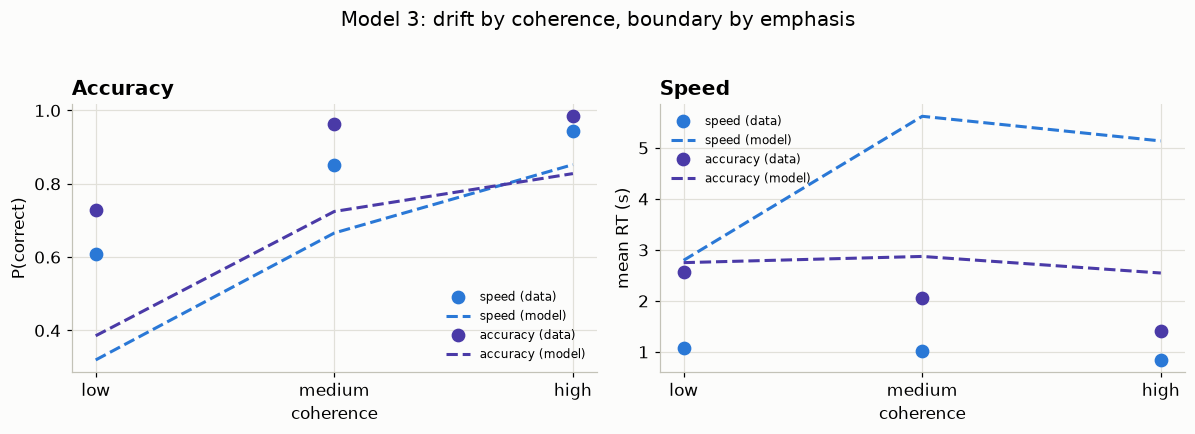

In [8]:
# Model 3: drift varies by coherence AND boundary varies by emphasis.
with pm.Model(coords=COORDS) as m3_both:
    # Priors
    v = pm.Normal("v", 0.0, 3.0, dims="coherence")
    a = pm.HalfNormal("a", 2.0, dims="emphasis")
    z = pm.Beta("z", 5.0, 5.0)
    t = pm.HalfNormal("t", 0.5)
    # Likelihood
    DDM("obs", v=v[coh_idx], a=a[emp_idx], z=z, t=t, observed=observed)

idata_both = fit(m3_both)
pred_both = cell_predictions(idata_both, m3_both)
compare_plot(pred_both, "Model 3: drift by coherence, boundary by emphasis")

Model 2 captures the accuracy pattern and still misses the RT pattern —
it has no way to separate the two emphasis conditions. Model 3 tracks both.

## 4. Comparing models properly

Eyeballing predictions is necessary but not sufficient: a model with more
parameters can always fit better. **Leave-one-out cross-validation** (LOO)
estimates out-of-sample predictive accuracy, so it penalises complexity that
does not pay for itself.

First, the transparent version: how far is each model's prediction from the
data, summed over the six design cells?

In [9]:
def discrepancy(preds):
    """Mean absolute error in predicted accuracy and mean RT, across cells."""
    joined = summary.join(preds, rsuffix="_pred")
    return pd.Series({
        "accuracy MAE": (joined["accuracy"] - joined["accuracy_pred"]).abs().mean(),
        "mean RT MAE": (joined["mean_rt"] - joined["mean_rt_pred"]).abs().mean(),
    })


preds_all = {"1: flat": pred_flat,
             "2: drift by coherence": pred_drift,
             "3: drift + boundary": pred_both}
print(pd.DataFrame({k: discrepancy(v) for k, v in preds_all.items()}).T
        .to_string(float_format=lambda v: f"{v:.4f}"))

                       accuracy MAE  mean RT MAE
1: flat                      0.1189       0.5496
2: drift by coherence        0.0456       0.5172
3: drift + boundary          0.2175       2.1250


That ranks the models but says nothing about **overfitting** — a model with
more parameters will generally track the data more closely whether or not the
extra flexibility is real. For that we want an estimate of *out-of-sample*
predictive accuracy. `az.loo` provides one via leave-one-out
cross-validation.

In [10]:
for name, idata in [("1: flat", idata_flat),
                    ("2: drift by coherence", idata_drift),
                    ("3: drift + boundary", idata_both)]:
    try:
        loo = az.loo(idata)
        k = loo.pareto_k.values
        bad = int((k > 0.7).sum())
        print(f"{name:24s} elpd_loo = {float(loo.elpd):9.1f}   "
              f"p_loo = {float(loo.p):6.1f}   Pareto k > 0.7: {bad:3d}/{k.size}")
    except Exception as exc:
        # Not defensive programming for its own sake — see the callout below.
        print(f"{name:24s} LOO FAILED: {type(exc).__name__}: {exc}")

1: flat                  elpd_loo =   -2291.1   p_loo =    3.9   Pareto k > 0.7:   0/1500


2: drift by coherence    elpd_loo =   -2136.7   p_loo =    5.8   Pareto k > 0.7:   0/1500
3: drift + boundary      LOO FAILED: ValueError: All tail values are the same


<details class="sbi-warn" open>
<summary>⚠️ <b>Read the Pareto <i>k</i> column before the elpd column</b></summary>

LOO does not refit the model 1500 times; it *reweights* the existing draws,
and that shortcut only works when no single observation dominates the weights.
The Pareto $k$ diagnostic detects when it fails, and values above about 0.7
mean the estimate for that point is not to be trusted.

Look at what model 1 did. Depending on the draw it either reports a `p_loo` —
nominally the effective number of parameters — of several hundred for a model
with **four**, or it fails outright with `All tail values are the same`.
Neither is a discovery about the model; both are LOO telling you it could not
do its job. A grossly misspecified model makes some observations so
surprising that those points dominate the importance weights, and the Pareto
fit that LOO relies on has nothing left to work with.

So: use LOO to separate *plausible* models from each other, and use posterior
predictive plots to reject the implausible ones. Do not ask LOO to rank a
model that the plots already told you is wrong.

</details>

## 5. What actually generated the data

Time to look behind the curtain.

In [11]:
print("TRUE generating parameters")
print("  drift by coherence :", _V_BY_COHERENCE)
print("  boundary by emphasis:", _A_BY_EMPHASIS)
print(f"  start point z = {_Z_TRUE},  non-decision time t = {_T_TRUE}\n")

post = idata_both.posterior.dataset
print("Model 3 recovery")
for i, coh in enumerate(CONDITIONS):
    est = post["v"].values[..., i]
    print(f"  v[{coh:<6}] {est.mean():5.2f} +/- {est.std():.2f}"
          f"   (true {_V_BY_COHERENCE[coh]})")
for i, emp in enumerate(EMPHASES):
    est = post["a"].values[..., i]
    print(f"  a[{emp:<8}] {est.mean():5.2f} +/- {est.std():.2f}"
          f" (true {_A_BY_EMPHASIS[emp]})")
print(f"  z          {post['z'].values.mean():5.2f} +/- {post['z'].values.std():.2f}"
      f"   (true {_Z_TRUE})")
print(f"  t          {post['t'].values.mean():5.2f} +/- {post['t'].values.std():.2f}"
      f"   (true {_T_TRUE})")

TRUE generating parameters
  drift by coherence : {'low': 0.35, 'medium': 0.85, 'high': 1.5}
  boundary by emphasis: {'speed': 0.9, 'accuracy': 1.6}
  start point z = 0.5,  non-decision time t = 0.3

Model 3 recovery
  v[low   ] -0.34 +/- 0.63   (true 0.35)
  v[medium]  0.42 +/- 0.44   (true 0.85)
  v[high  ]  0.81 +/- 0.63   (true 1.5)
  a[speed   ]  2.03 +/- 1.13 (true 0.9)
  a[accuracy]  1.63 +/- 0.02 (true 1.6)
  z           0.52 +/- 0.01   (true 0.5)
  t           0.68 +/- 0.37   (true 0.3)


Model 3 **is** the generating model, and it recovers the parameters. That is
the happy case, and it is worth being explicit about why it went well:

- the design has enough trials per cell,
- the manipulations act on **different** parameters, so they do not compete,
- and the error rates are moderate, which we will discover in half an hour is
  not a small thing.

<details class="sbi-warn" open>
<summary>⚠️ <b>The comparison found the right model. It could not have told you it was <i>correct</i>.</b></summary>

LOO ranks the candidates **you** proposed. If the true model is not among
them, comparison happily hands you the best of a bad set, with no hint that
anything is missing. That is what posterior predictive plots are for — they
compare a model against the *data*, not against its rivals. Use both.

</details>

### Exercise

Fit a fourth model in which **coherence acts on the boundary** and
**emphasis acts on the drift** — the mapping deliberately swapped. Add it to
the comparison.

Predict first: will it fit better or worse than model 1? Than model 3?

<details>
<summary>Solution and what to notice</summary>

```python
with pm.Model(coords=COORDS) as m4_swapped:
    v = pm.Normal("v", 0.0, 3.0, dims="emphasis")
    a = pm.HalfNormal("a", 2.0, dims="coherence")
    z = pm.Beta("z", 5.0, 5.0)
    t = pm.HalfNormal("t", 0.5)
    DDM("obs", v=v[emp_idx], a=a[coh_idx], z=z, t=t, observed=observed)

idata_swapped = fit(m4_swapped)
for nm, idt in [("3: drift + boundary", idata_both), ("4: swapped", idata_swapped)]:
    loo = az.loo(idt)
    print(f"{nm:22s} elpd_loo = {float(loo.elpd):9.1f}")
compare_plot(cell_predictions(idata_swapped, m4_swapped), "Model 4: swapped")
```

It fits **much better than model 1** — it has the same number of parameters
as model 3 and can bend both curves, so it soaks up a lot of the structure.
It fits **worse than model 3**, and the predictive plot shows why: it can
make accuracy depend on emphasis and RT depend on coherence, which is the
wrong way round, so it cannot reproduce both patterns at once.

The lesson is that "more flexible" and "right" are different things. A model
can have exactly the right number of parameters, fit far better than nothing,
and still be telling you a false story about the mechanism.

</details>


### Where this goes

Writing `v[coh_idx]` by hand gets old quickly. On **Day 3 at 09:30** the same
model is one line:

```python
hssm.HSSM(data=data, model="ddm",
          include=[{"name": "v", "formula": "v ~ 0 + C(coherence)"},
                   {"name": "a", "formula": "a ~ 0 + C(emphasis)"}])
```

**Next, at 15:00:** we stop assuming the sampler works. Everything today
converged quietly — that is not guaranteed, and the failures are more
interesting than the successes.